In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.2
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## DATA LOADING AND PREPROCESSING

In [3]:
train_image_dir = 'data/train/images'
train_label_dir = 'data/train/labels'
valid_image_dir = 'data/valid/images'
valid_label_dir = 'data/valid/labels'

In [4]:
def parse_yolo_label(label_path):
    """
    Parse YOLO format label file and return class ID
    YOLO format: class_id x_center y_center width height
    Returns: class_id (0-5) or,1 if file is empty
    """
    try:
        with open(label_path, 'r') as f:
            content = f.read().strip()
            if content:
                # Get first line's class ID
                class_id = int(content.split()[0])
                return class_id
            return,1  # Empty file (no object)
    except:
        return,1

In [5]:
def create_binary_labels(image_dir, label_dir, target_class=0):
    """
    Create binary classification dataset
    target_class: The class we want to detect (default: 0 = car)
    Returns: image_paths, binary_labels (1 = target class, 0 = other classes)
    """
    image_paths = []
    binary_labels = []
    
    for img_file in os.listdir(image_dir):
        if not (img_file.endswith('.jpg') or img_file.endswith('.jpeg')):
            continue
        
        # Get corresponding label file
        img_name = os.path.splitext(img_file)[0]
        label_file = img_name + '.txt'
        label_path = os.path.join(label_dir, label_file)
        
        if not os.path.exists(label_path):
            continue
        
        # Parse label
        class_id = parse_yolo_label(label_path)
        
        if class_id ==,1:  # Skip empty labels
            continue
        
        # Create binary label: 1 if target_class, 0 otherwise
        binary_label = 1 if class_id == target_class else 0
        
        image_paths.append(os.path.join(image_dir, img_file))
        binary_labels.append(binary_label)
    
    return np.array(image_paths), np.array(binary_labels)

In [6]:
# Load training and validation data
print("Loading training data...")
train_paths, train_labels = create_binary_labels(train_image_dir, train_label_dir, target_class=0)

print("Loading validation data...")
valid_paths, valid_labels = create_binary_labels(valid_image_dir, valid_label_dir, target_class=0)

Loading training data...
Loading validation data...


In [7]:
print("\nDATASET STATISTICS   :\n")
print(f"Training samples: {len(train_paths)}")
print(f" , Cars (class 1): {np.sum(train_labels)} ({np.mean(train_labels)*100:.1f}%)")
print(f" , Other vehicles (class 0): {len(train_labels), np.sum(train_labels)} ({(1-np.mean(train_labels))*100:.1f}%)")
print(f"\nValidation samples: {len(valid_paths)}")
print(f" , Cars (class 1): {np.sum(valid_labels)} ({np.mean(valid_labels)*100:.1f}%)")
print(f" , Other vehicles (class 0): {len(valid_labels), np.sum(valid_labels)} ({(1-np.mean(valid_labels))*100:.1f}%)")


DATASET STATISTICS   :

Training samples: 2057
  - Cars (class 1): 345 (16.8%)
  - Other vehicles (class 0): 1712 (83.2%)

Validation samples: 888
  - Cars (class 1): 156 (17.6%)
  - Other vehicles (class 0): 732 (82.4%)


## IMAGE PREPROCESSING

In [10]:
IMG_SIZE = 224  # Input image size
BATCH_SIZE = 32

def preprocess_image(img_path, label):
    """Load and preprocess a single image"""
    # Read image file
    img = tf.io.read_file(img_path)
    # Decode as RGB
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize to target size
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Normalize to [0, 1]
    img = img / 255.0
    return img, label

In [11]:
# Create TensorFlow datasets 
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths.astype(str), train_labels.astype(np.float32)))
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((valid_paths.astype(str), valid_labels.astype(np.float32)))
valid_dataset = valid_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
print("\nDATA PIPELINE READY:\n")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"Batch size: {BATCH_SIZE}")


DATA PIPELINE READY:

Image size: 224x224 RGB
Batch size: 32


## BASELINE MODEL (NO REGULARIZATION)

In [14]:
def build_baseline_cnn():
    """
    Baseline CNN Architecture (≥4 convolutional layers)
    NO regularization, this is intentional to see if we have bias or variance problems
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    return model

# Build and compile baseline model
baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/imadeddine/miniconda3/envs/datasci/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
print("\nBASELINE MODEL ARCHITECTURE\n")
baseline_model.summary()


BASELINE MODEL ARCHITECTURE



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## TRAINING BASELINE MODEL

In [16]:
print("\nTRAINING BASELINE MODEL (NO REGULARIZATION):\n")

BASELINE_EPOCHS = 20

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=BASELINE_EPOCHS,
    verbose=1
)


TRAINING BASELINE MODEL (NO REGULARIZATION):

Epoch 1/20


2025-11-21 01:33:46.017718: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.7876 - loss: 0.5120 - val_accuracy: 0.8243 - val_loss: 0.4560
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8279 - loss: 0.4639 - val_accuracy: 0.1745 - val_loss: 2.1648
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.7764 - loss: 0.5800 - val_accuracy: 0.8243 - val_loss: 0.5900
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8303 - loss: 0.4438 - val_accuracy: 0.8221 - val_loss: 0.4468
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7210 - loss: 0.8437 - val_accuracy: 0.8243 - val_loss: 0.6055
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.8201 - loss: 0.9993 - val_accuracy: 0.8333 - val_loss: 0.8915
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.7846 - loss: 1.4856 - val_accuracy: 0.6227 - val_loss: 4.2947
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.7307 - loss: 3.9772 - val_accuracy: 0.7556 - val_loss:

## BASELINE DIAGNOSTIC ANALYSIS

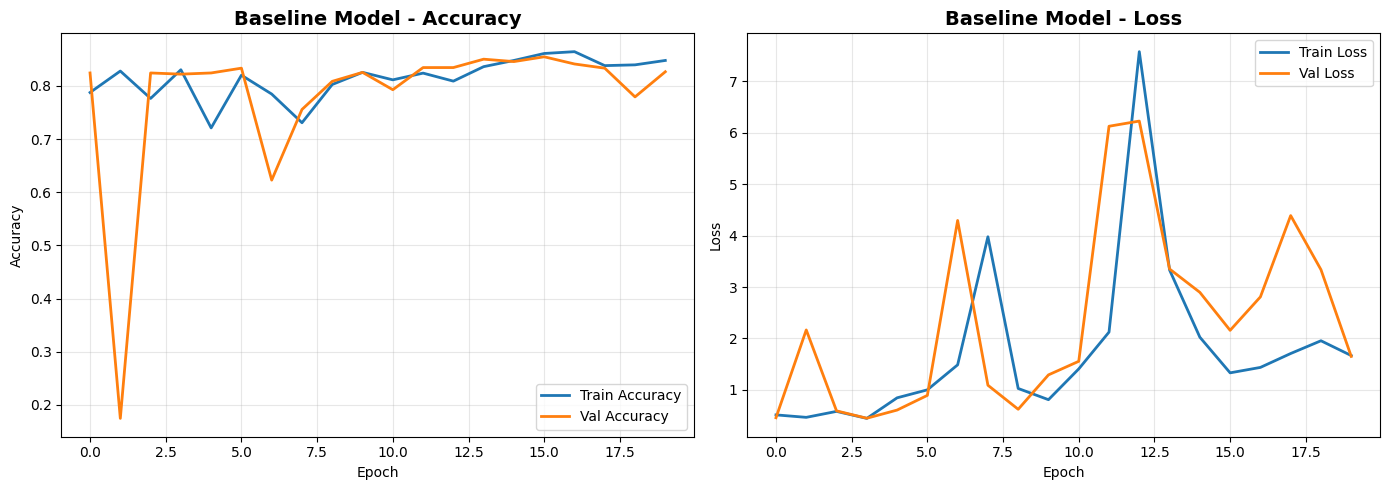

In [18]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation accuracy/loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{title}, Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{title}, Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot baseline results
plot_training_history(baseline_history, "Baseline Model")

In [19]:
# Calculate final metrics
final_train_acc = baseline_history.history['accuracy'][-1]
final_val_acc = baseline_history.history['val_accuracy'][-1]
accuracy_gap = final_train_acc, final_val_acc

In [20]:
print("BASELINE MODEL DIAGNOSTIC ANALYSIS\n")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Accuracy Gap (Train, Val): {accuracy_gap:.4f}")

BASELINE MODEL DIAGNOSTIC ANALYSIS

Final Training Accuracy: 0.8478
Final Validation Accuracy: 0.8266
Accuracy Gap (Train - Val): 0.0213


In [30]:
# Evaluate per-class metrics
print("Analyzing per-class performance...\n")

# Get predictions
y_true = []
y_pred = []

for images, labels in valid_dataset:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(
    y_true, 
    y_pred, 
    target_names=['Not Car', 'Car'],
    output_dict=True
)

print("PER-CLASS PERFORMANCE:")
print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 48)
for class_name in ['Not Car', 'Car']:
    m = report[class_name]
    print(f"{class_name:<12} {m['precision']:<12.3f} {m['recall']:<12.3f} {m['f1-score']:<12.3f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nCONFUSION MATRIX:")
print(f"{'':>12} Predicted")
print(f"{'':>12} Not Car  Car")
print(f"True Not Car {cm[0,0]:>7}  {cm[0,1]:>4}")
print(f"     Car     {cm[1,0]:>7}  {cm[1,1]:>4}")


Analyzing per-class performance...

PER-CLASS PERFORMANCE:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Not Car      0.879        0.915        0.897       
Car          0.508        0.410        0.454       

CONFUSION MATRIX:
             Predicted
             Not Car  Car
True Not Car     670    62
     Car          92    64


2025-11-21 01:48:44.246368: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Diagnostic Interpretation

## Key Findings

1. Overall accuracy (82.7%) is barely better than always predicting the majority class (82.4%)

2. Car Detection Performance (minority class):
  , Recall: 41.0%, Missing 59% of actual cars!
  , Precision: 50.8%, Only ~50% confidence when predicting 'car'
  , F1-Score: 0.454

## Root Cause Analysis

This is NOT a bias/variance problem. This IS a CLASS IMBALANCE problem.

The model is biased toward the majority class (Not Car: 82.4%). During training, it learned that predicting 'Not Car' is usually correct, so it became conservative about predicting 'Car'.

## Action Plan

To address class imbalance, we will:

1. Apply CLASS WEIGHTS to penalize minority class errors more
2. Add REGULARIZATION (Dropout + L2) to prevent overfitting
3. Use CALLBACKS for optimal training control

This combination should help the model:
- Pay more attention to car examples during training
- Learn more robust features
- Generalize better to new data

## CALCULATE CLASS WEIGHTS

In [33]:
print("CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA: \n")

# Calculate class weights to balance the training
# Formula: weight = total_samples / (num_classes * samples_per_class)
total_train = len(train_labels)
num_train_not_car = np.sum(train_labels == 0)
num_train_car = np.sum(train_labels == 1)

weight_not_car = total_train / (2 * num_train_not_car)
weight_car = total_train / (2 * num_train_car)

class_weights = {
    0: weight_not_car,  # Not Car
    1: weight_car       # Car
}

print(f"Training set distribution:")
print(f"- Not Car (0): {num_train_not_car} samples")
print(f"- Car (1): {num_train_car} samples")
print(f"- Imbalance ratio: {num_train_not_car/num_train_car:.2f}:1")
print(f"\nCalculated class weights:")
print(f"- Not Car (0): {weight_not_car:.3f}")
print(f"- Car (1): {weight_car:.3f}")
print(f"- Weight ratio: {weight_car/weight_not_car:.2f}x more penalty for Car errors")

CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA: 

Training set distribution:
- Not Car (0): 1712 samples
- Car (1): 345 samples
- Imbalance ratio: 4.96:1

Calculated class weights:
- Not Car (0): 0.601
- Car (1): 2.981
- Weight ratio: 4.96x more penalty for Car errors


## OPTIMIZED MODEL WITH REGULARIZATION

In [35]:
def build_optimized_cnn(use_dropout=True, use_l2=True, dropout_rate=0.5, l2_rate=0.01):
    """
    Optimized CNN with regularization techniques
   , Dropout: Randomly drops neurons during training to prevent overfitting
   , L2 Regularization: Penalizes large weights to prevent overfitting
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Conv Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten
        layers.Flatten(),
        
        # Dense layers with regularization
        layers.Dense(
            128, 
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_rate) if use_l2 else None
        ),
    ])
    
    # Add Dropout if specified
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer with L2 regularization
    model.add(layers.Dense(
        1, 
        activation='sigmoid',
        kernel_regularizer=regularizers.l2(l2_rate) if use_l2 else None
    ))
    
    return model

In [43]:
# Build optimized model, we'll use regularization for class imbalance problem
print("Applying: Dropout (0.4)\n        + L2 Regularization (0.01)\n        + Class Weights to address imbalance")
optimized_model = build_optimized_cnn(use_dropout=True, use_l2=True, dropout_rate=0.4, l2_rate=0.01)

optimized_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

optimized_model.summary()

Applying: Dropout (0.4)
        + L2 Regularization (0.01)
        + Class Weights to address imbalance


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## ADDING CALLBACKS FOR BETTER TRAINING CONTROL

In [45]:
print("CONFIGURING TRAINING CALLBACKS:\n")

# Callback 1: Early Stopping, Stop training when validation loss stops improving
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', # Watch validation loss
    patience=7, # Wait 7 epochs before stopping
    restore_best_weights=True, # Restore weights from best epoch
    verbose=1
)
print("- Early Stopping: Prevents wasting time on non-improving training")

# Callback 2: Model Checkpoint, Save the best model during training
model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy', # Save based on best validation accuracy
    save_best_only=True,
    verbose=1
)
print("- Model Checkpoint: Saves best model weights automatically")

# Callback 3: Reduce Learning Rate, Lower LR when stuck
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # Reduce LR by half
    patience=4, # Wait 4 epochs before reducing
    verbose=1,
    min_lr=1e-7
)
print("- Reduce LR on Plateau: Helps escape local minima")

CONFIGURING TRAINING CALLBACKS:

- Early Stopping: Prevents wasting time on non-improving training
- Model Checkpoint: Saves best model weights automatically
- Reduce LR on Plateau: Helps escape local minima


## TRAINING OPTIMIZED MODEL WITH CLASS WEIGHTS

In [46]:
print("TRAINING OPTIMIZED MODEL:\n")
print("\nTraining with:")
print(f"  • Class weights (Car errors count {weight_car/weight_not_car:.1f}x more)")
print("  • Dropout (0.4) for regularization")
print("  • L2 regularization (0.01)")
print("  • Early stopping, checkpointing, and LR reduction\n")

OPTIMIZED_EPOCHS = 50  # Train longer, but early stopping will stop if needed

optimized_history = optimized_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=OPTIMIZED_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

TRAINING OPTIMIZED MODEL:


Training with:
  • Class weights (Car errors count 5.0x more)
  • Dropout (0.4) for regularization
  • L2 regularization (0.01)
  • Early stopping, checkpointing, and LR reduction

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6897 - loss: 1.6347
Epoch 1: val_accuracy improved from None to 0.17568, saving model to best_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.6670 - loss: 1.0956 - val_accuracy: 0.1757 - val_loss: 0.9560 - learning_rate: 0.0010
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4918 - loss: 0.7201
Epoch 2: val_accuracy improved from 0.17568 to 0.82545, saving model to best_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.5994 - loss: 0.7188 - val_accuracy: 0.8255 - val_loss: 0.6117 - learning_rate: 0.0010
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7016 - loss: 0.6555
Epoch 3: val_accuracy did not improve from 0.82545
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7122 - loss: 0.6376 - val_accuracy: 0.6633 - val_loss: 0.7155 - learning_rate: 0.0010
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6719 - loss: 0.7374
Epoch 4: val_accuracy did not improve from 0.82545
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.7287 - loss: 0.7462 - val_accuracy: 0.8018 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7161 - loss: 0.6530
Epoch 5: val_accuracy improved from 0.82545 to 0.83896, saving model to best_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.7049 - loss: 0.6427 - val_accuracy: 0.8390 - val_loss: 0.5148 - learning_rate: 0.0010
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7498 - loss: 0.5944
Epoch 6: val_accuracy did not improve from 0.83896
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.7414 - loss: 0.6344 - val_accuracy: 0.7252 - val_loss: 0.6260 - learning_rate: 0.0010
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7944 - loss: 0.6267
Epoch 7: val_accuracy improved from 0.83896 to 0.84685, saving model to best_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7832 - loss: 0.6061 - val_accuracy: 0.8468 - val_loss: 0.4830 - learning_rate: 0.0010
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7771 - loss: 0.5623
Epoch 8: val_accuracy did not improve from 0.84685
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.7637 - loss: 0.5885 - val_accuracy: 0.6791 - val_loss: 0.6545 - learning_rate: 0.0010
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7381 - loss: 0.6332
Epoch 9: val_accuracy did not improve from 0.84685
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.7253 - loss: 0.7025 - val_accuracy: 0.6532 - val_loss: 0.6710 - learning_rate: 0.0010
Epoch 10/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7846 - loss: 0.5435
Epoch 10: val_accuracy did not improve from 0.84685
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.8216 - loss: 0.5124 - val_accuracy: 0.7218 - val_loss: 0.6461 - learning_rate: 0.0010
Epoch 11/50
65/65 ━━━━━━━━━━

65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.8172 - loss: 0.4824 - val_accuracy: 0.8975 - val_loss: 0.3630 - learning_rate: 0.0010
Epoch 12/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7728 - loss: 0.5216
Epoch 12: val_accuracy did not improve from 0.89752
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.7885 - loss: 0.4907 - val_accuracy: 0.8795 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 13/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8279 - loss: 0.4311
Epoch 13: val_accuracy did not improve from 0.89752
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.8026 - loss: 0.4938 - val_accuracy: 0.8232 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 14/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8274 - loss: 0.4564
Epoch 14: val_accuracy did not improve from 0.89752
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.8498 - loss: 0.4249 - val_accuracy: 0.8964 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 15/50
65/65 ━━━━━━━

65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.8721 - loss: 0.3698 - val_accuracy: 0.8986 - val_loss: 0.2961 - learning_rate: 0.0010
Epoch 21/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8886 - loss: 0.3213
Epoch 21: val_accuracy did not improve from 0.89865
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.8974 - loss: 0.3130 - val_accuracy: 0.8480 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 22/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8978 - loss: 0.3129
Epoch 22: val_accuracy did not improve from 0.89865
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.8814 - loss: 0.3341 - val_accuracy: 0.7489 - val_loss: 0.5554 - learning_rate: 0.0010
Epoch 23/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8829 - loss: 0.3020
Epoch 23: val_accuracy did not improve from 0.89865
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.8765 - loss: 0.3302 - val_accuracy: 0.8975 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 24/50
65/65 ━━━━━━

65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.9246 - loss: 0.2742 - val_accuracy: 0.9099 - val_loss: 0.2847 - learning_rate: 5.0000e-04
Epoch 26/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9308 - loss: 0.2536
Epoch 26: val_accuracy did not improve from 0.90991
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9261 - loss: 0.2513 - val_accuracy: 0.8998 - val_loss: 0.3000 - learning_rate: 5.0000e-04
Epoch 27/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9208 - loss: 0.2593
Epoch 27: val_accuracy did not improve from 0.90991
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9276 - loss: 0.2454 - val_accuracy: 0.8716 - val_loss: 0.3824 - learning_rate: 5.0000e-04
Epoch 28/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9079 - loss: 0.2613
Epoch 28: val_accuracy improved from 0.90991 to 0.91104, saving model to best_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.9208 - loss: 0.2451 - val_accuracy: 0.9110 - val_loss: 0.2986 - learning_rate: 5.0000e-04
Epoch 29/50
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9155 - loss: 0.2735
Epoch 29: val_accuracy did not improve from 0.91104

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9251 - loss: 0.2409 - val_accuracy: 0.9054 - val_loss: 0.2918 - learning_rate: 5.0000e-04
Epoch 30/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9382 - loss: 0.2292
Epoch 30: val_accuracy did not improve from 0.91104
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9353 - loss: 0.2190 - val_accuracy: 0.9020 - val_loss: 0.3012 - learning_rate: 2.5000e-04
Epoch 31/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9471 - loss: 0.1977
Epoch 31: val_accuracy did not improve from 0.91104
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9431 - loss: 0.2032 - 

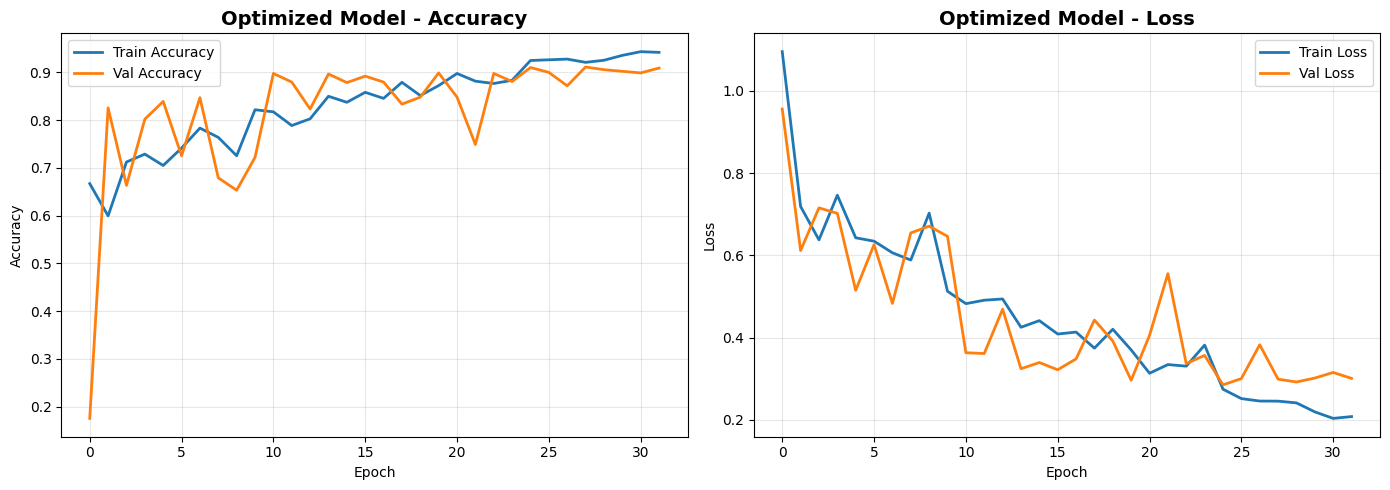

In [47]:
# Plot optimized results
plot_training_history(optimized_history, "Optimized Model")

## FINAL EVALUATION

In [48]:
print("FINAL MODEL EVALUATION:\n")

# Load best model
best_model = keras.models.load_model('best_model.h5')

# Evaluate on validation set
val_loss, val_accuracy = best_model.evaluate(valid_dataset, verbose=0)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

FINAL MODEL EVALUATION:



Validation Loss: 0.2986
Validation Accuracy: 0.9110


In [52]:
# Generate predictions for detailed metrics
y_true = []
y_pred = []

for images, labels in valid_dataset:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=['Other Vehicles', 'Car']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("CONFUSION MATRIX\n")
print("                 Predicted")
print("                 Other  Car")
print(f"Actual Other     {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"       Car       {cm[1,0]:4d}   {cm[1,1]:4d}")

CLASSIFICATION REPORT

                precision    recall  f1-score   support

Other Vehicles       0.91      0.98      0.95       732
           Car       0.89      0.56      0.69       156

      accuracy                           0.91       888
     macro avg       0.90      0.77      0.82       888
  weighted avg       0.91      0.91      0.90       888

CONFUSION MATRIX

                 Predicted
                 Other  Car
Actual Other      721     11
       Car         68     88


2025-11-21 02:01:47.840205: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## COMPARISON:

In [60]:
# Compare key metrics
print("RESULTS:\n")
print(f"                 Baseline  →  Optimized  →  Improvement")
print(f"Overall Acc:      82.7%        91.1%         +8.4%")
print(f"Car Precision:    50.8%        88.9%        +38.1% ")
print(f"Car Recall:       41.0%        56.4%        +15.4%")

RESULTS:

                 Baseline  →  Optimized  →  Improvement
Overall Acc:      82.7%        91.1%         +8.4%
Car Precision:    50.8%        88.9%        +38.1% 
Car Recall:       41.0%        56.4%        +15.4%


**Problem Identified:** CLASS IMBALANCE (82.4% not-car, 17.6% car)     
  • Baseline was barely better than 'always predict not-car'    
  • Car detection was essentially random (51% precision)     
    
**Solution Applied:**
  • Class Weights (4.96x penalty for car errors)     
  • Dropout (0.4) + L2 Regularization (0.01)     
  • Early Stopping + Model Checkpointing      

**Outcome:**     
  • Car precision: coin flip → highly confident (89%)    
  • Car recall: still moderate (56%, missing 44% of cars)...     

**KEY INSIGHT:**
Class weights made the model conservative but accurate:     
  • When it says 'car', it's right 89% of the time    
  • But it misses many cars to avoid false alarms    
  • Trade-off: High precision, moderate recall    